## **Do forwards produce a significantly higher rate of combined goals and assists per ninety minutes than midfielders at the 2026 World Cup?**

**Reasoning:** Forwards are expected to score more goals and make more assists per game because their main job is to play near the opponent goal and finish attack plays. Midfielders spend more time defending and passing the ball in the middle of the field, so they have fewer direct chances to score or make assists.

**Population:** The study includes forward and midfielder players who played a total of at least ninety minutes at the tournament. Players who are listed under more than one main position, such as players marked as both forward and midfielder, are removed so every player belongs to only one clear group.

**Test:** A two sample t-test is used to compare the average scoring rates of two separate groups, which are forwards and midfielders.

**Data Source:**  The data comes from the website FBref, which contains player statistics from the 2026 World Cup that were organized and cleaned into a single file by our team.

## **1. Setup**

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

DATA_FILE = "players_data.csv"
SAMPLE_SIZE = 60
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

## **2. Data Wrangling**

In [14]:
data = pd.read_csv(DATA_FILE)
print(f"Total players loaded: {len(data)}")

# Keep only forwards and midfielders with a single clear position label
df = data[(data["pos"] == "FW") | (data["pos"] == "MF")].copy()

# Ensure minutes played is numeric and filter for at least 90 minutes
df["minutes"] = pd.to_numeric(df["minutes"], errors="coerce")
df = df[df["minutes"] >= 90].copy()

# Extract and clean Goals + Assists per 90 column
df["ga_per90"] = pd.to_numeric(
    df["standard_per_90_minutes_g+a"], errors="coerce"
)
df = df.dropna(subset=["ga_per90"])

print(
    f"\nPopulation after wrangling: {len(df)} players "
    f"({(df['pos']=='FW').sum()} FW, {(df['pos']=='MF').sum()} MF)"
)
df[["player", "pos", "squad", "minutes", "ga_per90"]].head()

Total players loaded: 1039

Population after wrangling: 346 players (96 FW, 250 MF)


,player,pos,squad,minutes,ga_per90
1,Thelo Aasgaard,MF,no Norway,90,1.0
8,Yusuf Abdurisag,FW,qa Qatar,98,0.0
16,Ché Adams,FW,sct Scotland,145,0.0
17,Jayden Adams,MF,za South Africa,116,0.0
18,Tyler Adams,MF,us USA,341,0.0


## **3. Data Preparation & Sampling**

In [15]:
forwards_pop = df[df["pos"] == "FW"]
midfielders_pop = df[df["pos"] == "MF"]

forwards_sample = forwards_pop.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED)
midfielders_sample = midfielders_pop.sample(
    n=SAMPLE_SIZE, random_state=RANDOM_SEED
)

sample = pd.concat([forwards_sample, midfielders_sample], ignore_index=True)
print(
    f"Sample drawn: n={len(sample)} "
    f"({(sample['pos']=='FW').sum()} FW, {(sample['pos']=='MF').sum()} MF)"
)
sample[["player", "pos", "squad", "ga_per90"]].head()

Sample drawn: n=120 (60 FW, 60 MF)


,player,pos,squad,ga_per90
0,Luis Suárez,FW,co Colombia,0.27
1,Eldor Shomurodov,FW,uz Uzbekistan,0.33
2,Patrik Schick,FW,cz Czechia,0.00
3,Yoane Wissa,FW,cd Congo DR,0.75
4,Hwang Hee-chan,FW,kr Korea Republic,0.00


## **4. Descriptive Statistics**

In [16]:
desc = sample.groupby("pos")["ga_per90"].agg(
    [
        "count",
        "mean",
        "std",
        "median",
        lambda x: x.quantile(0.25),
        lambda x: x.quantile(0.75),
    ]
)
desc.columns = ["n", "mean", "sd", "median", "Q1", "Q3"]
desc.round(3)

,n,mean,sd,median,Q1,Q3
pos,,,,,,
FW,60,0.540,0.597,0.44,0.0,0.878
MF,60,0.209,0.272,0.00,0.0,0.402


## **5. Inferential Statistics(Confidence Interval)**

In [17]:
fw = sample.loc[sample["pos"] == "FW", "ga_per90"]
mf = sample.loc[sample["pos"] == "MF", "ga_per90"]

for label, group in [("Forwards", fw), ("Midfielders", mf)]:
  n = len(group)
  mean, se = group.mean(), group.std(ddof=1) / np.sqrt(n)
  ci_low, ci_high = stats.t.interval(0.95, df=n - 1, loc=mean, scale=se)
  print(
      f"{label}: mean = {mean:.3f}  95% CI = [{ci_low:.3f}, {ci_high:.3f}] "
      f" (n={n})"
  )

Forwards: mean = 0.540  95% CI = [0.385, 0.694]  (n=60)
Midfielders: mean = 0.209  95% CI = [0.139, 0.279]  (n=60)


## **6. Inferential Statistics (Two-Sample t-Test)**

In [18]:
# Welch's two-sample t-test (equal_var=False)
t_stat, p_val = stats.ttest_ind(fw, mf, equal_var=False)

print(f"Forwards:    n={len(fw)}, mean={fw.mean():.3f}, sd={fw.std(ddof=1):.3f}")
print(
    f"Midfielders: n={len(mf)}, mean={mf.mean():.3f}, sd={mf.std(ddof=1):.3f}"
)
print(f"t = {t_stat:.3f}, p = {p_val:.4f}")

verdict = (
    "statistically significant"
    if p_val < 0.05
    else "not statistically significant"
)
print(f"--> Difference is {verdict} at alpha = 0.05")

Forwards:    n=60, mean=0.540, sd=0.597
Midfielders: n=60, mean=0.209, sd=0.272
t = 3.902, p = 0.0002
--> Difference is statistically significant at alpha = 0.05


## **7. Visualisation**

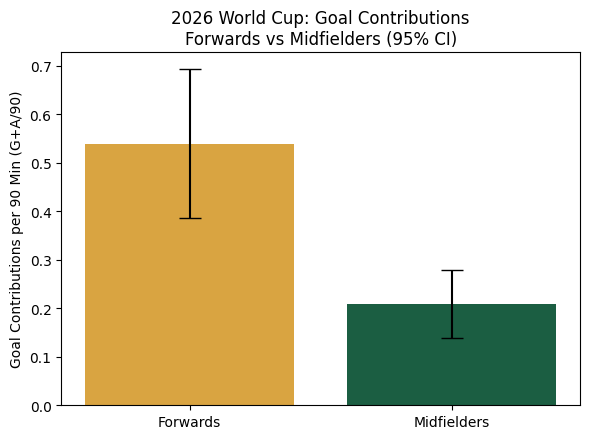

In [19]:
fig, ax = plt.subplots(figsize=(6, 4.5))
groups = ["Forwards", "Midfielders"]
means = [fw.mean(), mf.mean()]
errs = [
    fw.std(ddof=1) / np.sqrt(len(fw)) * stats.t.ppf(0.975, len(fw) - 1),
    mf.std(ddof=1) / np.sqrt(len(mf)) * stats.t.ppf(0.975, len(mf) - 1),
]

ax.bar(groups, means, yerr=errs, capsize=8, color=["#d9a441", "#1b5e42"])
ax.set_ylabel("Goal Contributions per 90 Min (G+A/90)")
ax.set_title(
    "2026 World Cup: Goal Contributions\nForwards vs Midfielders (95% CI)"
)
plt.tight_layout()
plt.savefig("ga_per90_by_position.png", dpi=150)
plt.show()